In [21]:
from notebook import * 

my name: bowen han

my netid: bhan001

my github repo for hw2: https://github.com/UCR-HPC/cs211-hw2-solving-large-linear-system-private-bugparty

my best speed of my_block on block size 5000: 1.438684

how to run: make && ./main my_block 5000


# Q1

$$ 
A = \begin{pmatrix}
1 & 2 & 3 \\
4 & 13 & 18 \\
7 & 54 & 78
\end{pmatrix}
$$


$$ r_2-4r_1   \rightarrow
 \begin{pmatrix}
1 & 2 & 3 \\
0 & 5 & 6 \\
7 & 54 & 78
\end{pmatrix}
$$

$$ r_3-7r_1   \rightarrow
 \begin{pmatrix}
1 & 2 & 3 \\
0 & 5 & 6 \\
0 & 40 & 57
\end{pmatrix}
$$

$$ r_3-8r_2   \rightarrow
A_4 = \begin{pmatrix}
1 & 2 & 3 \\
0 & 5 & 6 \\
0 & 0 & 9
\end{pmatrix}
$$

$$ U = \begin{pmatrix}
1 & 2 & 3 \\
0 & 5 & 6 \\
0 & 0 & 9
\end{pmatrix}$$

$$ I = \begin{pmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & 0 & 1
\end{pmatrix}$$

$$ r_3+8r_2 \rightarrow \begin{pmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & 8 & 1
\end{pmatrix}$$

$$ r_3+7r_1 \rightarrow \begin{pmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
7 & 8 & 1
\end{pmatrix}$$

$$ r_2+4r_1  \rightarrow \begin{pmatrix}
1 & 0 & 0 \\
4 & 1 & 0 \\
7 & 8 & 1
\end{pmatrix}$$

$$ L  \rightarrow \begin{pmatrix}
1 & 0 & 0 \\
4 & 1 & 0 \\
7 & 8 & 1
\end{pmatrix}$$

$$ A = \begin{pmatrix}
1 & 0 & 0 \\
4 & 1 & 0 \\
7 & 8 & 1
\end{pmatrix}\begin{pmatrix}
1 & 2 & 3 \\
0 & 5 & 6 \\
0 & 0 & 9
\end{pmatrix} = L\times U$$

Q2

In [24]:
! make bench
! srun ./bench.sh |tee  q2.csv

make: 'bench' is up to date.
size,padding,function,time
1000,1,my,0.134903
1000,1,lapack,0.050966
2000,1,my,1.250594
2000,1,lapack,0.218658
3000,1,my,5.459690
3000,1,lapack,0.654219
4000,1,my,14.899835
4000,1,lapack,1.319266
5000,1,my,29.157335
5000,1,lapack,2.633189


In [5]:
display_mono(render_csv("q2.csv"))

,index,n,padding,function,time
0,0,1000,1,my,0.134594
1,1,1000,1,lapack,0.051083
2,2,2000,1,my,1.258278
3,3,2000,1,lapack,0.219119
4,4,3000,1,my,5.461538
5,5,3000,1,lapack,0.655299
6,6,4000,1,my,14.231517
7,7,4000,1,lapack,1.318260
8,8,5000,1,my,29.169058
9,9,5000,1,lapack,2.631429


the core of the computation is here.
```
for (i=0;i<n-1;++i){
for(j=i+1; j<n; ++j){
            A[j*n+i] /=  A[i*n+i];
            for(k=i+1;k<n;++k){
                A[j*n+k] -= A[j*n+i]*A[i*n+k];
            }
        }
}
```
total flops will be
$$\sum_{i=0}^{n-2}(\sum_{j=i+1}^{n-1}(1+\sum_{k=i+1}^{n-1}\times 2))$$
simplified, we got
$$ \frac{n(n-1)(4n+1)}{6}$$

,size,function,time,Gflops
0,1000,my,0.134594,4.949452
1,1000,lapack,0.051083,13.040865
2,2000,my,1.258278,4.237007
3,2000,lapack,0.219119,24.330765
4,3000,my,5.461538,3.294951
5,3000,lapack,0.655299,27.461509
6,4000,my,14.231517,2.997478
7,4000,lapack,1.318260,32.359827
8,5000,my,29.169058,2.856480
9,5000,lapack,2.631429,31.663721


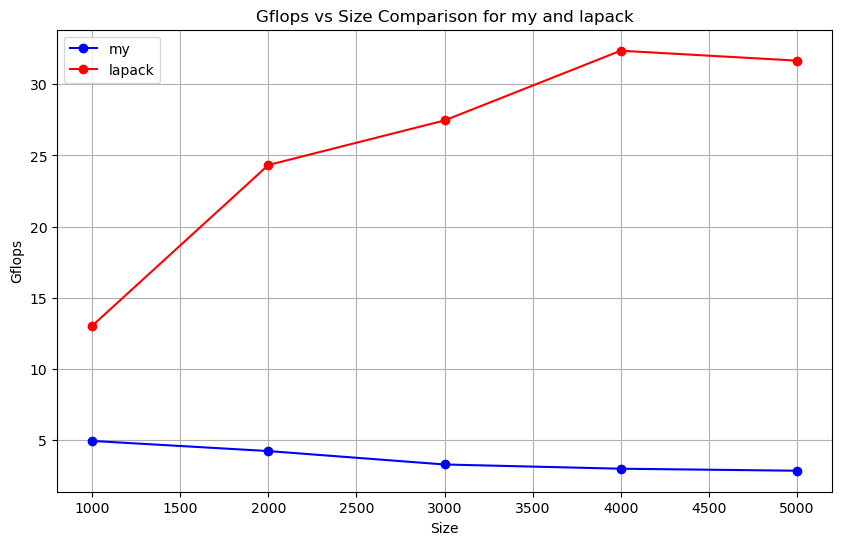

In [8]:
import pandas as pd
import numpy as np
file_path = 'q2.csv'
data = pd.read_csv(file_path)
data.columns = data.columns.str.strip()
data.drop('padding', axis=1, inplace=True)
data['time'] = data['time'].astype(float)
data['Gflops'] = (data['size']*(data['size']-1)*(4*data['size']+1)/6) / data['time'] / 1e9
my_data = data[data['function'] == 'my']
lapack_data = data[data['function'] == 'lapack']

plt.figure(figsize=(10, 6))
plt.plot(my_data['size'], my_data['Gflops'], marker='o', linestyle='-', color='b', label='my')
plt.plot(lapack_data['size'], lapack_data['Gflops'], marker='o', linestyle='-', color='r', label='lapack')

plt.xlabel('Size')
plt.ylabel('Gflops')
plt.title('Gflops vs Size Comparison for my and lapack')
plt.legend()
plt.grid(True)

display(data)
plt.show()

from the chart above, we can conclude that lapack Gflops growth very well when data size is growing , but my naive one Gflops drops when data size grows.

# Q3

$$ 
A = \begin{pmatrix}
1 & 2 & 3 & 4\\
2 & 9 & 12 & 15 \\
3 & 26 & 41 & 49 \\
5 & 40 & 107 & 135
\end{pmatrix}
$$

first we work on left part, A(1:4,1:2),

divide A(2:4,1:2) by A(1,1)

still the same matrix.

then subtract A(2:4,2) , we got

$$ 
A = \begin{pmatrix}
1 & 2 & 3 & 4\\
2 & 5 & 12 & 15 \\
3 & 20 & 41 & 49 \\
5 & 30 & 107 & 135
\end{pmatrix}
$$
work on A(2:4,2) again 
$$ 
A = \begin{pmatrix}
1 & 2 & 3 & 4\\
2 & 5 & 12 & 15 \\
3 & 4 & 41 & 49 \\
5 & 6 & 107 & 135
\end{pmatrix}
$$

then we work on U part, which is A(1:2,3:4)

$$ 
A = \begin{pmatrix}
1 & 2 & 3 & 4\\
2 & 5 & 6 & 7 \\
3 & 4 & 41 & 49 \\
5 & 6 & 107 & 135
\end{pmatrix}
$$

then update the square matrix A(3:4,3:4)

$$ 
A = \begin{pmatrix}
1 & 2 & 3 & 4\\
2 & 5 & 6 & 7 \\
3 & 4 & 8 & 9 \\
5 & 6 & 56 & 73
\end{pmatrix}
$$

2nd iteration on A(3:4,3:4)

$$ 
A = \begin{pmatrix}
1 & 2 & 3 & 4\\
2 & 5 & 6 & 7 \\
3 & 4 & 8 & 9 \\
5 & 6 & 7 & 10
\end{pmatrix}
$$

Q4


In [11]:
! make bench
! srun ./bench2.sh |tee  q4.csv

make: 'bench' is up to date.
size,padding,function,time
1000,1,my,0.134645
1000,1,my_block,0.018651
1000,1,lapack,0.049278
2000,1,my,1.263703
2000,1,my_block,0.106673
2000,1,lapack,0.218466
3000,1,my,5.483605
3000,1,my_block,0.325652
3000,1,lapack,0.652902
4000,1,my,14.230608
4000,1,my_block,0.736560
4000,1,lapack,1.321099
5000,1,my,29.237753
5000,1,my_block,1.452024
5000,1,lapack,2.636767


In [12]:
display_mono(render_csv("q4.csv"))

,index,size,padding,function,time
0,0,1000,1,my,0.134645
1,1,1000,1,my_block,0.018651
2,2,1000,1,lapack,0.049278
3,3,2000,1,my,1.263703
4,4,2000,1,my_block,0.106673
5,5,2000,1,lapack,0.218466
6,6,3000,1,my,5.483605
7,7,3000,1,my_block,0.325652
8,8,3000,1,lapack,0.652902
9,9,4000,1,my,14.230608


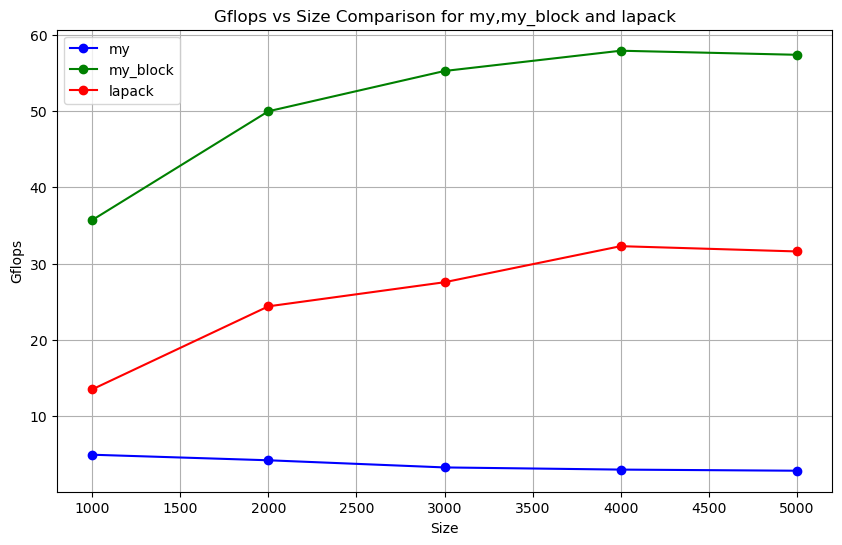

In [15]:
import pandas as pd
import numpy as np
file_path = 'q4.csv'
data = pd.read_csv(file_path)
data.columns = data.columns.str.strip()
data.drop('padding', axis=1, inplace=True)
data['time'] = data['time'].astype(float)
data['Gflops'] = (data['size']*(data['size']-1)*(4*data['size']+1)/6) / data['time'] / 1e9
my_data = data[data['function'] == 'my']
my_block_data = data[data['function'] == 'my_block']
lapack_data = data[data['function'] == 'lapack']

plt.figure(figsize=(10, 6))
plt.plot(my_data['size'], my_data['Gflops'], marker='o', linestyle='-', color='b', label='my')
plt.plot(my_block_data['size'], my_block_data['Gflops'], marker='o', linestyle='-', color='g', label='my_block')
plt.plot(lapack_data['size'], lapack_data['Gflops'], marker='o', linestyle='-', color='r', label='lapack')

plt.xlabel('Size')
plt.ylabel('Gflops')
plt.title('Gflops vs Size Comparison for my,my_block and lapack')
plt.legend()
plt.grid(True)

plt.show()


,size,function,time,Gflops
0,1000,my,0.134645,4.947577
1,1000,my_block,0.018651,35.717468
2,1000,lapack,0.049278,13.518538
3,2000,my,1.263703,4.218818
4,2000,my_block,0.106673,49.978279
5,2000,lapack,0.218466,24.403491
6,3000,my,5.483605,3.281691
7,3000,my_block,0.325652,55.259908
8,3000,lapack,0.652902,27.562329
9,4000,my,14.230608,2.997670


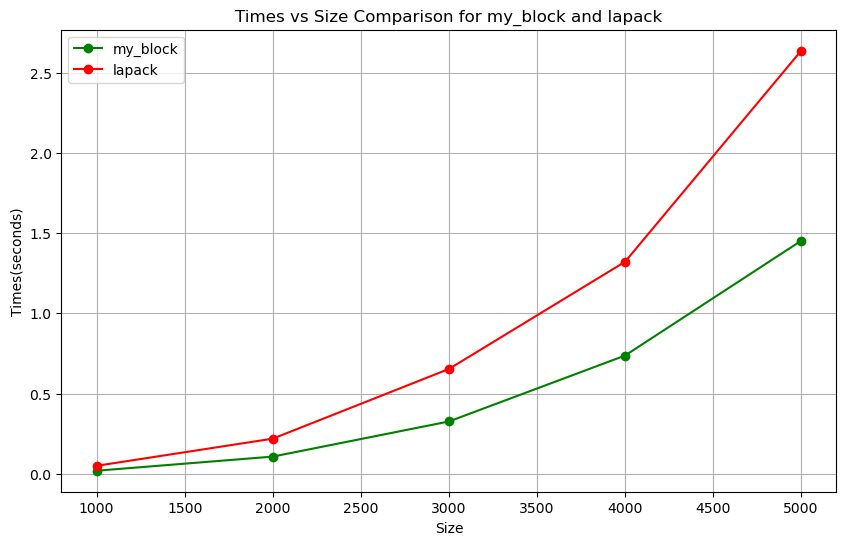

In [22]:
plt.figure(figsize=(10, 6))
plt.plot(my_block_data['size'], my_block_data['time'], marker='o', linestyle='-', color='g', label='my_block')
plt.plot(lapack_data['size'], lapack_data['time'], marker='o', linestyle='-', color='r', label='lapack')

plt.xlabel('Size')
plt.ylabel('Times(seconds)')
plt.title('Times vs Size Comparison for my_block and lapack')
plt.legend()
plt.grid(True)

display(data)
plt.show()

## you can see my_block version is two times faster than lapack 

## what I did to imporve the performance

before optimzation, the first  bottleneck is the gemm kernel, I ported my previous kernel which use avx512 , then when n=5000, execution time is about 5s.

later I reliazed when block size is small, IC is huge, overhead of the blocking is high, so that's why it is slow, so I increased the block size, I tried 64,96,128,256, 128 is the best, test agianist n=5000, execution time is about 2.5s.

then I adopt the partial pivoting, which means in the blocked_gemm, I only swap a partial of each rows, later I will swap the rest in two steps, in this way, it will not invalid the cache too much, it will not trigger as much of capacity miss than before, test agianist n=5000, execution time is about 2.2s.

then I played with padding size, when padding size is 48, test agianist n=5000, run time is about 2.1s. I think it is because it reduced the conflict miss.

from this time, gemm kernel is not the bottle neck anymore, but the top right coner update become the bottle neck, I didn't optimzate that part before, so I apply the loop order interchage and simple register reuse.
then test agianist n=5000, execution time is about 1.452024s. 

### here is my experiment with difference outter loop of the gemm3 

naive gemm 6s
matrix size 2048
block size 64
gemm2_ikj with kernel gemm2_kernel_ikj 1.733647s
gemm2_ikj with kernel gemm2_kernel_ijk  time=5.221353s
gemm2_kij with kernel gemm2_kernel_ikj time=1.798215s
gemm2_kij with kernel gemm2_kernel_ijk time=5.256797s


block size 32
gemm2_ikj with kernel gemm2_kernel_ikj time=1.474892s
gemm2_ikj with kernel gemm2_kernel_ijk  time=3.529859s
gemm2_kij with kernel gemm2_kernel_ikj time=1.466103s
gemm2_kij with kernel gemm2_kernel_ijk time=3.308022s

block size 16

gemm2_ikj with kernel gemm2_kernel_ikj time=1.850689s
gemm2_ikj with kernel gemm2_kernel_ijk time=2.014001s

gemm2_kij with kernel gemm2_kernel_ikj time=1.856311s
gemm2_kij with kernel gemm2_kernel_ijk time=2.023650s


block size 8

gemm2_ikj with kernel gemm2_kernel_ikj time=2.161841s

gemm2_ikj with kernel gemm2_kernel_ijk time=1.038547s

gemm2_kij with kernel gemm2_kernel_ikj time=2.164994s

gemm2_kij with kernel gemm2_kernel_ijk time=1.043894s

### my best blocked vs unblocked

n=1024, pad=1

time=0.142120s

n=1024, pad=1

time=0.133448s

n=2048, pad=1

time=1.419077s

n=2048, pad=1

time=1.045721s

n=3072, pad=1

time=6.314619s

n=3072, pad=1

time=3.471887s

n=4096, pad=1

time=15.780349s

n=4096, pad=1

time=10.072522s

n=5120, pad=1

time=31.659635s

n=5120, pad=1

time=16.001343s
